# YOLOv8n vs YOLOv8s vs YOLOv10n — Crack Detection


### CELL 1: Setup

In [ ]:
import os
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from ultralytics import YOLO

# -------------------------------
# Paths & Config
# -------------------------------
ROOT         = Path.cwd()
SRC_DATASET  = ROOT / 'Crack.v2-2026-4-12_augumented.yolov8'   # raw Roboflow export
PREP_DATASET = ROOT / 'crack_bbox'                             # auto-generated (bbox labels)
DATA_PATH    = PREP_DATASET / 'dataset.yaml'
RUNS_DIR     = ROOT / 'runs' / 'detect'

EPOCHS   = 80
LR       = 1e-3
IMG_SIZE = 649
BATCH    = 8 #16

# -------------------------------
# Device setup
# -------------------------------
device = 0 if torch.cuda.is_available() else 'cpu'
sns.set_style('whitegrid')

print('Device:', device)
print('Setup complete')

Device: 0
Setup complete ✅


### CELL 2: Prepare dataset  (polygons → bboxes, writes dataset.yaml)

Roboflow exported this as YOLOv8 **segmentation** (polygon labels). Ultralytics detection models need `class cx cy w h`. This cell writes a sibling `crack_bbox/` with converted labels + symlinked images. Safe to re-run.

In [ ]:
def poly_to_bbox(line):
    parts = line.strip().split()
    if not parts: return None
    cls, coords = parts[0], [float(x) for x in parts[1:]]
    if len(coords) == 4:  return line.strip()               # already bbox
    if len(coords) < 6 or len(coords) % 2: return None
    xs, ys = coords[::2], coords[1::2]
    x0, x1 = max(0.0, min(xs)), min(1.0, max(xs))
    y0, y1 = max(0.0, min(ys)), min(1.0, max(ys))
    w, h = x1 - x0, y1 - y0
    if w <= 0 or h <= 0: return None
    return f'{cls} {x0 + w/2:.6f} {y0 + h/2:.6f} {w:.6f} {h:.6f}'


for split in ['train', 'valid', 'test']:
    src_img = SRC_DATASET / split / 'images'
    src_lbl = SRC_DATASET / split / 'labels'
    if not src_img.exists():
        continue
    dst_img = PREP_DATASET / split / 'images'
    dst_lbl = PREP_DATASET / split / 'labels'
    dst_img.parent.mkdir(parents=True, exist_ok=True)
    dst_lbl.mkdir(parents=True, exist_ok=True)
    if not dst_img.exists() and not dst_img.is_symlink():
        try:
            os.symlink(src_img.resolve(), dst_img, target_is_directory=True)
        except (OSError, NotImplementedError):
            shutil.copytree(src_img, dst_img)
    n = 0
    for txt in src_lbl.glob('*.txt'):
        out = []
        for ln in txt.read_text().splitlines():
            c = poly_to_bbox(ln)
            if c: out.append(c); n += 1
        (dst_lbl / txt.name).write_text('\n'.join(out) + ('\n' if out else ''))
    print(f'  {split:5s}: {n} boxes')

DATA_PATH.write_text(
    f'path: {PREP_DATASET.resolve()}\n'
    f'train: train/images\n'
    f'val: valid/images\n'
    f'test: test/images\n'
    f'nc: 1\n'
    f"names: ['Crack']\n"
)
print('Dataset prep complete')

  train: 3963 boxes
  valid: 391 boxes
  test : 187 boxes
Dataset prep complete ✅


### CELL 3: Train YOLOv8n

In [ ]:
model_v8n = YOLO('yolov8n.pt')

results_v8n = model_v8n.train(
    data=str(DATA_PATH),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=device,
    project=str(RUNS_DIR),
    name='yolov8n_model',
    exist_ok=True,
)

print('YOLOv8n training completed')

Ultralytics 8.4.39 🚀 Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24068MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/samy/Niyati/edge_ai_project/crack_bbox/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=649, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_model, nbs=64, nms=False, opset=None, optimize=False, opt

2026-04-20 14:51:00,879	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-20 14:51:01,038	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

### CELL 4: Train YOLOv8s   (the "YOLO8" in the comparison — small variant)

In [ ]:
model_v8s = YOLO('yolov8s.pt')

results_v8s = model_v8s.train(
    data=str(DATA_PATH),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=device,
    project=str(RUNS_DIR),
    name='yolov8s_model',
    exist_ok=True,
)

print('YOLOv8s training completed')

Ultralytics 8.4.39 🚀 Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24068MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/samy/Niyati/edge_ai_project/crack_bbox/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=649, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_model, nbs=64, nms=False, opset=None, optimize=False, opt

### CELL 5: Train YOLOv10n

In [ ]:
model_v10n = YOLO('yolov10n.pt')

results_v10n = model_v10n.train(
    data=str(DATA_PATH),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=device,
    project=str(RUNS_DIR),
    name='yolov10n_model',
    exist_ok=True,
)

print('YOLOv10n training completed')

Ultralytics 8.4.39 🚀 Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24068MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/samy/Niyati/edge_ai_project/crack_bbox/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=649, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov10n_model, nbs=64, nms=False, opset=None, optimize=False, o

### CELL 6: Evaluate all three on the test split + collect metrics

In [ ]:
MODELS = {
    'yolov8n':  'yolov8n_model',
    'yolov8s':  'yolov8s_model',
    'yolov10n': 'yolov10n_model',
}

rows = {}
for name, run_dir in MODELS.items():
    best_pt = RUNS_DIR / run_dir / 'weights' / 'best.pt'
    m = YOLO(str(best_pt))
    r = m.val(
        data=str(DATA_PATH),
        split='test',
        imgsz=IMG_SIZE,
        batch=1,                                  # bs=1 for realistic per-image latency
        project=str(RUNS_DIR),
        name=f'{run_dir}_eval',
        exist_ok=True,
        plots=True,
        verbose=False,
        device=device,
    )
    n_params = sum(p.numel() for p in m.model.parameters())
    size_mb  = best_pt.stat().st_size / 1024**2
    total_ms = r.speed['preprocess'] + r.speed['inference'] + r.speed['postprocess']
    rows[name] = {
        'mAP50':        float(r.box.map50),
        'mAP50-95':     float(r.box.map),
        'precision':    float(r.box.mp),
        'recall':       float(r.box.mr),
        'params_M':     n_params / 1e6,
        'size_MB':      size_mb,
        'inference_ms': r.speed['inference'],
        'total_ms':     total_ms,
        'fps':          1000.0 / total_ms if total_ms else np.nan,
    }

df = pd.DataFrame(rows).T
df.index.name = 'model'
df.to_csv(ROOT / 'comparison_summary.csv')

print('Evaluation complete ')
df.round(3)

WARNING ⚠️ imgsz=[649] must be multiple of max stride 32, updating to [672]
Ultralytics 8.4.39 🚀 Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24068MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1652.3±1767.7 MB/s, size: 41.9 KB)
val: Scanning /home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8/test/labels.cache... 174 images, 61 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 174/174 66.3Mit/s 0.0s


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 174/174 83.3it/s 2.1s<0.0s
                   all        174        187      0.697      0.658      0.714      0.489
Speed: 0.8ms preprocess, 3.1ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /home/samy/Niyati/edge_ai_project/runs/detect/yolov8n_model_eval
WARNING ⚠️ imgsz=[649] must be multiple of max stride 32, updating to [672]
Ultralytics 8.4.39 🚀 Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24068MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1645.9±931.9 MB/s, size: 20.2 KB)
val: Scanning /home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8/test/labels.cache... 174 images, 61 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 174/174 34.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95

,mAP50,mAP50-95,precision,recall,params_M,size_MB,inference_ms,total_ms,fps
model,,,,,,,,,
yolov8n,0.714,0.489,0.697,0.658,3.006,5.968,3.118,5.964,167.660
yolov8s,0.686,0.480,0.761,0.615,11.126,21.484,3.253,5.859,170.688
yolov10n,0.639,0.428,0.665,0.610,2.265,5.494,5.263,7.160,139.674


In [7]:

%matplotlib inline

### CELL 7: Accuracy grouped bars

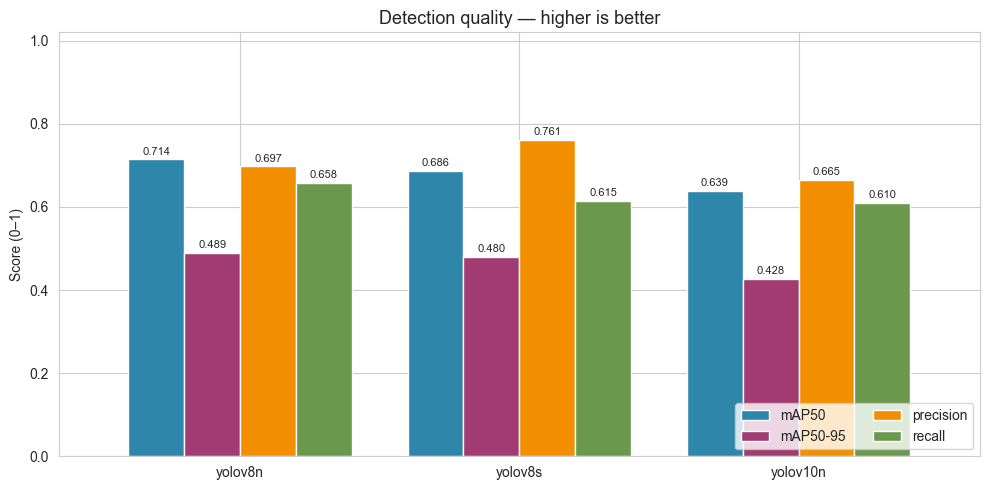

In [8]:
COLORS = {'yolov8n': '#2E86AB', 'yolov8s': '#A23B72', 'yolov10n': '#F18F01'}

fig, ax = plt.subplots(figsize=(10, 5))
df[['mAP50', 'mAP50-95', 'precision', 'recall']].plot(
    kind='bar', ax=ax, width=0.8,
    color=['#2E86AB', '#A23B72', '#F18F01', '#6A994E'])
ax.set_title('Detection quality — higher is better', fontsize=13, fontweight='bold')
ax.set_ylabel('Score (0–1)')
ax.set_xlabel('')
ax.set_ylim(0, 1.02)
ax.legend(loc='lower right', ncol=2)
plt.xticks(rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', padding=2, fontsize=8)
plt.tight_layout()
plt.savefig(ROOT / 'plot1_accuracy.png', dpi=150)
plt.show()

### CELL 8: Efficiency bars  (params, size, latency)

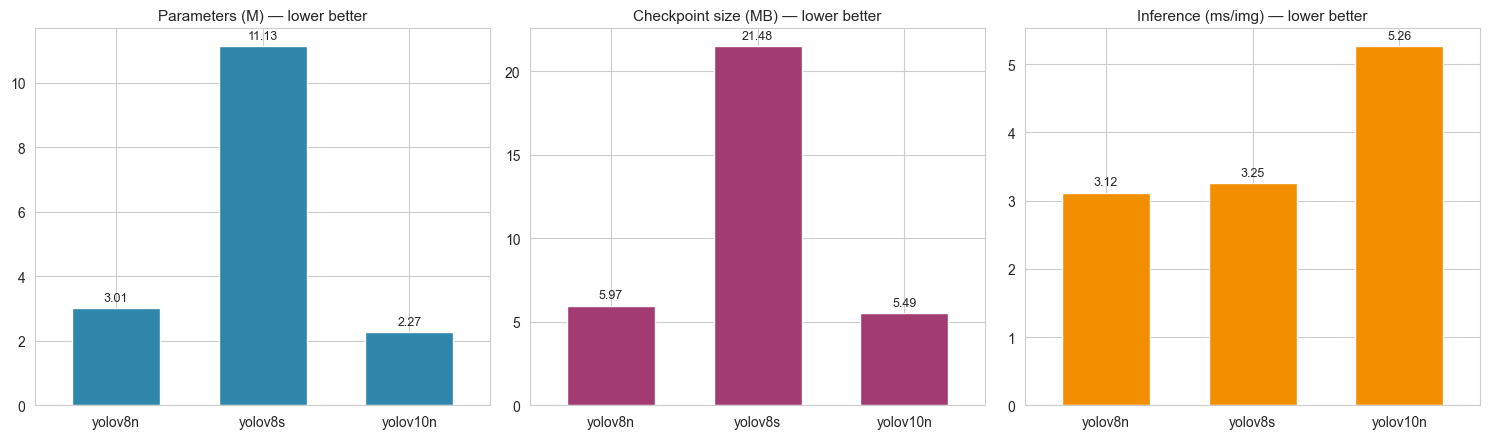

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
panels = [
    ('params_M',     'Parameters (M) — lower better',     '#2E86AB'),
    ('size_MB',      'Checkpoint size (MB) — lower better','#A23B72'),
    ('inference_ms', 'Inference (ms/img) — lower better',  '#F18F01'),
]
for ax, (col, title, color) in zip(axes, panels):
    df[col].plot(kind='bar', ax=ax, color=color, width=0.6)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.bar_label(ax.containers[0], fmt='%.2f', padding=3, fontsize=9)
    plt.setp(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(ROOT / 'plot2_efficiency.png', dpi=150)
plt.show()

### CELL 9: Pareto — mAP vs Size  (storage-constrained edge)

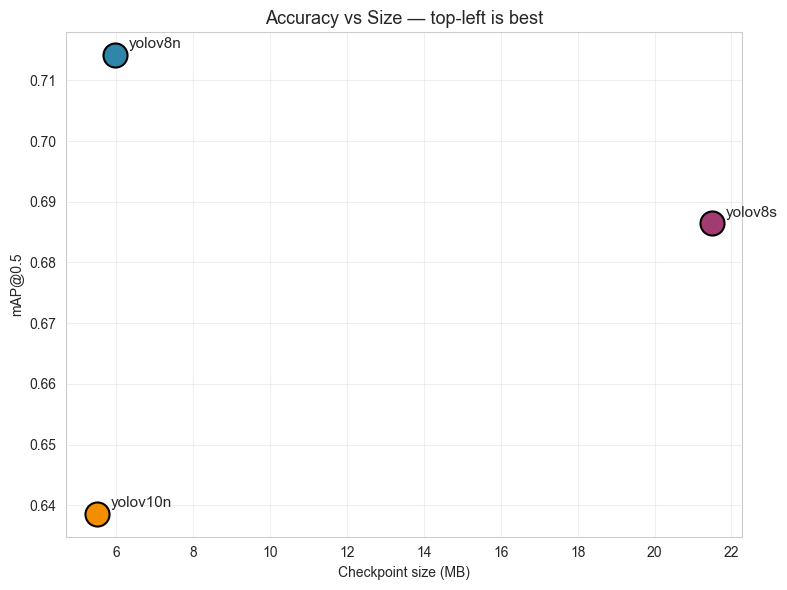

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
for name in df.index:
    ax.scatter(df.loc[name, 'size_MB'], df.loc[name, 'mAP50'],
               s=300, color=COLORS.get(name, 'gray'),
               edgecolor='black', linewidth=1.5, zorder=3)
    ax.annotate(name, (df.loc[name, 'size_MB'], df.loc[name, 'mAP50']),
                xytext=(10, 5), textcoords='offset points',
                fontsize=11, fontweight='bold')
ax.set_xlabel('Checkpoint size (MB)')
ax.set_ylabel('mAP@0.5')
ax.set_title('Accuracy vs Size — top-left is best',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'plot3_pareto_size.png', dpi=150)
plt.show()

### CELL 10: Pareto — mAP vs Latency  (real-time edge)

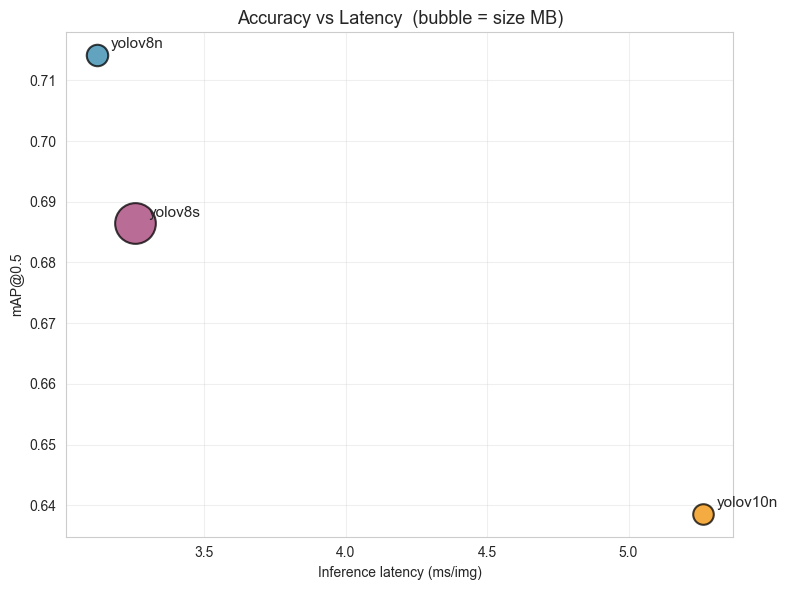

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
for name in df.index:
    ax.scatter(df.loc[name, 'inference_ms'], df.loc[name, 'mAP50'],
               s=df.loc[name, 'size_MB'] * 40, color=COLORS.get(name, 'gray'),
               edgecolor='black', linewidth=1.5, alpha=0.75, zorder=3)
    ax.annotate(name, (df.loc[name, 'inference_ms'], df.loc[name, 'mAP50']),
                xytext=(10, 5), textcoords='offset points',
                fontsize=11, fontweight='bold')
ax.set_xlabel('Inference latency (ms/img)')
ax.set_ylabel('mAP@0.5')
ax.set_title('Accuracy vs Latency  (bubble = size MB)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'plot4_pareto_latency.png', dpi=150)
plt.show()

### CELL 11: Training curves overlay  (from each run's results.csv)

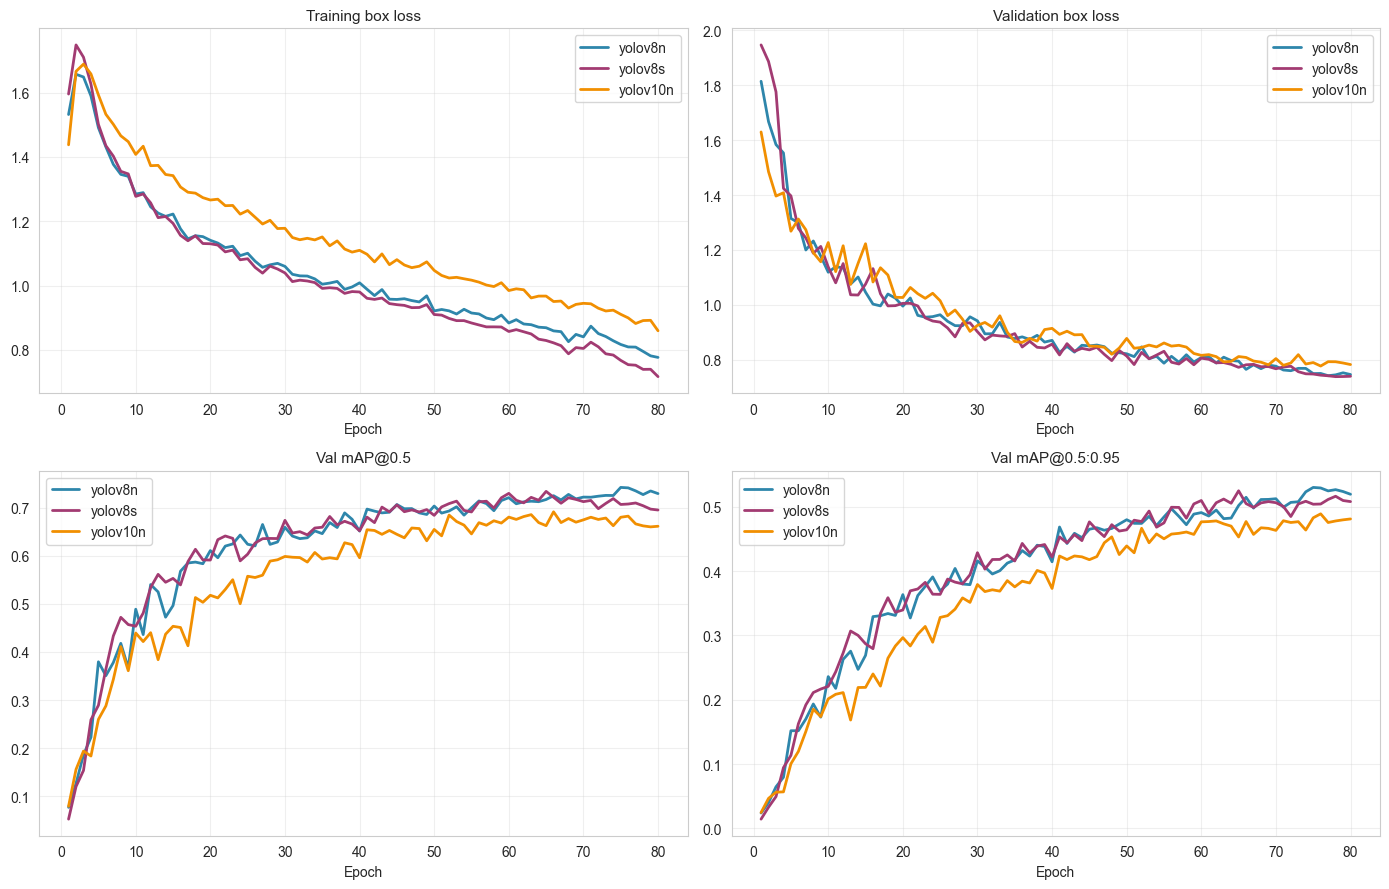

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
panels = [
    ((0, 0), 'train/box_loss',      'Training box loss'),
    ((0, 1), 'val/box_loss',        'Validation box loss'),
    ((1, 0), 'metrics/mAP50(B)',    'Val mAP@0.5'),
    ((1, 1), 'metrics/mAP50-95(B)', 'Val mAP@0.5:0.95'),
]
for (r, c), col, title in panels:
    ax = axes[r, c]
    for name, run_dir in MODELS.items():
        csv_path = RUNS_DIR / run_dir / 'results.csv'
        if not csv_path.exists():
            continue
        d = pd.read_csv(csv_path); d.columns = d.columns.str.strip()
        if col in d.columns:
            ax.plot(d['epoch'], d[col], label=name, linewidth=2,
                    color=COLORS.get(name, 'gray'))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'plot5_training_curves.png', dpi=150)
plt.show()

### CELL 12: Radar — holistic 6-axis comparison

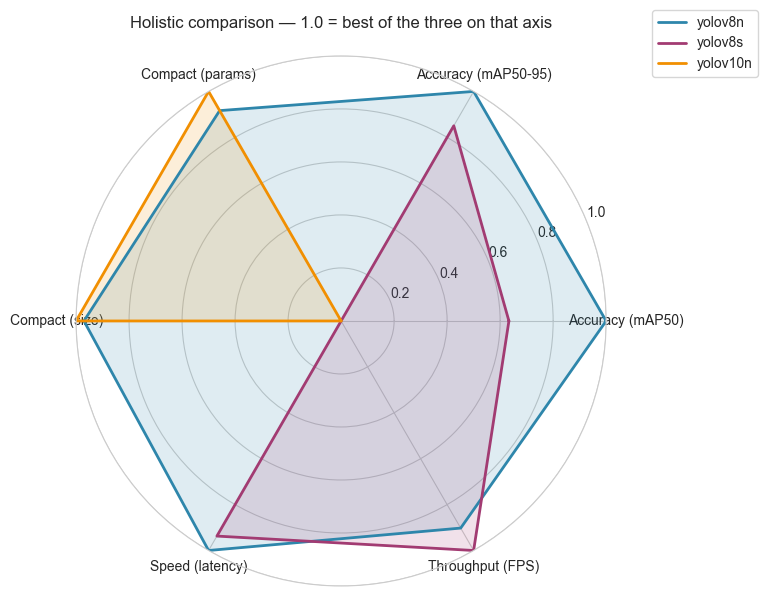

In [13]:
radar_cols = {
    'mAP50':        ('higher', 'Accuracy (mAP50)'),
    'mAP50-95':     ('higher', 'Accuracy (mAP50-95)'),
    'params_M':     ('lower',  'Compact (params)'),
    'size_MB':      ('lower',  'Compact (size)'),
    'inference_ms': ('lower',  'Speed (latency)'),
    'fps':          ('higher', 'Throughput (FPS)'),
}
norm = pd.DataFrame(index=df.index)
for col, (direction, _) in radar_cols.items():
    v = df[col]
    if direction == 'higher':
        norm[col] = (v - v.min()) / (v.max() - v.min() + 1e-9)
    else:
        norm[col] = (v.max() - v) / (v.max() - v.min() + 1e-9)

labels = [lbl for _, (_, lbl) in radar_cols.items()]
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
for name in norm.index:
    values = norm.loc[name].tolist(); values += values[:1]
    ax.plot(angles, values, linewidth=2, label=name, color=COLORS.get(name, 'gray'))
    ax.fill(angles, values, alpha=0.15, color=COLORS.get(name, 'gray'))
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Holistic comparison — 1.0 = best of the three on that axis',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(ROOT / 'plot6_radar.png', dpi=150)
plt.show()

### CELL 13: summary table 

In [14]:
(df
 .round({'mAP50':3,'mAP50-95':3,'precision':3,'recall':3,
         'params_M':2,'size_MB':2,
         'inference_ms':2,'total_ms':2,'fps':1})
 .style
 .background_gradient(subset=['mAP50','mAP50-95','precision','recall','fps'], cmap='Greens')
 .background_gradient(subset=['params_M','size_MB','inference_ms','total_ms'], cmap='Reds_r')
 .set_caption('Per-model summary'))

,mAP50,mAP50-95,precision,recall,params_M,size_MB,inference_ms,total_ms,fps
model,,,,,,,,,
yolov8n,0.714000,0.489000,0.697000,0.658000,3.010000,5.970000,3.120000,5.960000,167.700000
yolov8s,0.686000,0.480000,0.761000,0.615000,11.130000,21.480000,3.250000,5.860000,170.700000
yolov10n,0.639000,0.428000,0.665000,0.610000,2.270000,5.490000,5.260000,7.160000,139.700000
